# Day 7–8 · Data Preprocessing for ML Training

**Goal:** Merge `detailed_meals_macros_CLEANED.csv` + `Food_and_Nutrition__.csv`,  
clean them, create disease binary columns, and save a ready-to-train dataset.

**Output:** `merged_training_data.csv` — used by `02_model_training.ipynb` in Phase 2.

**Why merge two datasets?**  
Both files have the same 1,698 rows and identical `Disease` columns, but  
`detailed_meals_macros_CLEANED` has per-meal macro breakdown (breakfast/lunch/dinner)  
while `Food_and_Nutrition__` only has daily totals. We combine them for more features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../backend/app/data/'

meals_df = pd.read_csv(DATA_DIR + 'detailed_meals_macros_CLEANED.csv')
fn_df    = pd.read_csv(DATA_DIR + 'Food_and_Nutrition__.csv')

print('detailed_meals shape:', meals_df.shape)
print('food_nutrition shape:', fn_df.shape)

detailed_meals shape: (1698, 35)
food_nutrition shape: (1698, 19)


## Step 1: Standardize column names
Both CSVs use different casing. We rename to a consistent snake_case.

In [2]:
# Rename map — maps original CSV headers to clean snake_case names
# This makes the code below identical for both DataFrames
RENAME_MAP = {
    'Ages':                 'age',
    'Gender':               'gender',
    'Height':               'height_cm',
    'Weight':               'weight_kg',
    'Activity Level':       'activity_level',
    'Dietary Preference':   'dietary_pref',
    'Daily Calorie Target': 'calorie_target',
    'Protein':              'protein_target',     # daily protein target (g)
    'Sugar':                'sugar_target',       # daily sugar limit (g)
    'Sodium':               'sodium_target',      # daily sodium limit (mg)
    'Calories':             'calories',
    'Carbohydrates':        'carbs',
    'Fiber':                'fiber',
    'Fat':                  'fat',
    'Disease':              'disease',
    'Breakfast Suggestion': 'breakfast',
    'Lunch Suggestion':     'lunch',
    'Dinner Suggestion':    'dinner',
    'Snack Suggestion':     'snack',
}

meals_clean = meals_df.rename(columns=RENAME_MAP)
fn_clean    = fn_df.rename(columns=RENAME_MAP)

print('meals_clean columns:', list(meals_clean.columns[:10]), '...')
print('fn_clean columns   :', list(fn_clean.columns[:10]), '...')

meals_clean columns: ['age', 'gender', 'height_cm', 'weight_kg', 'activity_level', 'dietary_pref', 'calorie_target', 'protein_target', 'sugar_target', 'sodium_target'] ...
fn_clean columns   : ['age', 'gender', 'height_cm', 'weight_kg', 'activity_level', 'dietary_pref', 'calorie_target', 'protein_target', 'sugar_target', 'sodium_target'] ...


## Step 2: Find shared columns and merge
We only keep columns present in BOTH datasets so `pd.concat` doesn't create NaN-filled columns.

In [3]:
# Shared columns = columns available in both datasets after renaming
shared_cols = list(set(meals_clean.columns) & set(fn_clean.columns))
print(f'Shared columns ({len(shared_cols)}):')
print(sorted(shared_cols))

Shared columns (19):
['activity_level', 'age', 'breakfast', 'calorie_target', 'calories', 'carbs', 'dietary_pref', 'dinner', 'disease', 'fat', 'fiber', 'gender', 'height_cm', 'lunch', 'protein_target', 'snack', 'sodium_target', 'sugar_target', 'weight_kg']


In [4]:
# Concatenate both datasets — double the training examples
# ignore_index=True resets the row index from 0 to 3395
merged = pd.concat(
    [meals_clean[shared_cols], fn_clean[shared_cols]],
    ignore_index=True
)
print(f'Merged shape: {merged.shape}')
print(f'Disease null count: {merged["disease"].isnull().sum()}')

Merged shape: (3396, 19)
Disease null count: 0


## Step 3: Multi-label disease encoding

The `disease` column contains comma-separated lists like:
```
"Weight Gain, Hypertension, Heart Disease"
```
We need to convert this into **binary columns** (one per disease),  
because the ML model expects a fixed-size feature vector — not a string.

This is called **multi-label binarization**.

In [5]:
# These are all diseases that appear in the Disease column
# We use str.contains() per disease — handles multi-disease rows correctly
DISEASES = [
    'Weight Gain',
    'Hypertension',
    'Heart Disease',
    'Kidney Disease',
    'Diabetes',
    'Weight Loss',
    'Acne',
]

for disease in DISEASES:
    # Column name: 'Weight Gain' → 'has_weight_gain'
    col_name = 'has_' + disease.lower().replace(' ', '_')
    # str.contains() returns True if the disease appears anywhere in the string
    # na=False means NaN rows become 0 (not an error)
    merged[col_name] = merged['disease'].str.contains(disease, na=False).astype(int)

# Show disease frequency — important for handling class imbalance in ML
disease_cols = ['has_' + d.lower().replace(' ', '_') for d in DISEASES]
print('=== Disease label counts ===')
print(merged[disease_cols].sum().sort_values(ascending=False))

=== Disease label counts ===
has_weight_gain       3328
has_hypertension       584
has_heart_disease      578
has_kidney_disease     378
has_diabetes           132
has_acne               132
has_weight_loss          2
dtype: int64


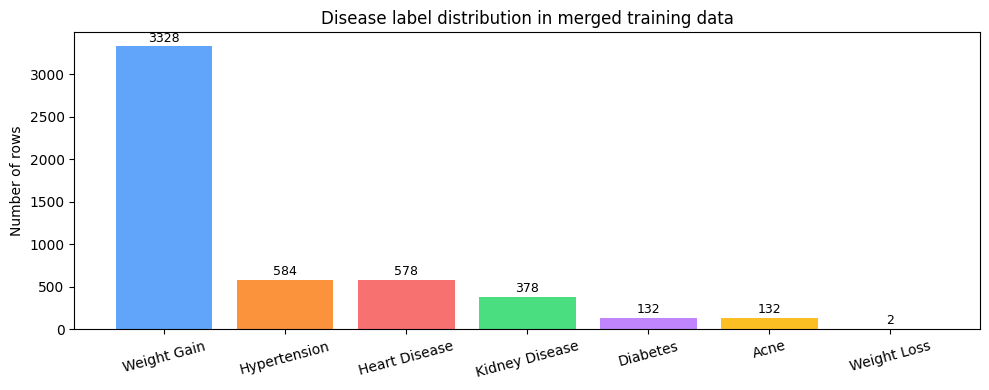

⚠ NOTE: Weight Gain dominates. Use class_weight="balanced" in your ML model.


In [6]:
# Visualize class imbalance
# Weight Gain dominates (2624 rows) — the ML model must handle this
# Solution: class_weight='balanced' in RandomForestClassifier
counts = merged[disease_cols].sum().sort_values(ascending=False)
labels = [c.replace('has_','').replace('_',' ').title() for c in counts.index]

plt.figure(figsize=(10, 4))
bars = plt.bar(labels, counts.values, color=['#60a5fa','#fb923c','#f87171','#4ade80','#c084fc','#fbbf24','#a78bfa'])
plt.title('Disease label distribution in merged training data')
plt.ylabel('Number of rows')
plt.xticks(rotation=15)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR + 'disease_distribution.png', dpi=100)
plt.show()
print('⚠ NOTE: Weight Gain dominates. Use class_weight="balanced" in your ML model.')

## Step 4: Clean numeric columns
Some columns have NaN values from the CSV. We fill numeric columns with median  
(median is better than mean for skewed distributions — less affected by outliers).

In [7]:
# Numeric columns we'll use as ML features
NUMERIC_COLS = [
    'age', 'height_cm', 'weight_kg',
    'calorie_target', 'protein_target', 'sugar_target', 'sodium_target',
    'calories', 'carbs', 'fiber', 'fat',
]

# Only fill columns that actually exist in the merged dataset
existing_numeric = [c for c in NUMERIC_COLS if c in merged.columns]

print('=== Null counts BEFORE fill ===')
print(merged[existing_numeric].isnull().sum())

=== Null counts BEFORE fill ===
age               0
height_cm         0
weight_kg         0
calorie_target    0
protein_target    0
sugar_target      0
sodium_target     0
calories          0
carbs             0
fiber             0
fat               0
dtype: int64


In [8]:
# Fill nulls with column median
for col in existing_numeric:
    median_val = merged[col].median()
    merged[col] = merged[col].fillna(median_val)
    
print('=== Null counts AFTER fill ===')
print(merged[existing_numeric].isnull().sum())
print('\nAll zeros = all nulls filled ✓')

=== Null counts AFTER fill ===
age               0
height_cm         0
weight_kg         0
calorie_target    0
protein_target    0
sugar_target      0
sodium_target     0
calories          0
carbs             0
fiber             0
fat               0
dtype: int64

All zeros = all nulls filled ✓


## Step 5: Encode categorical columns
ML models need numbers, not strings. We encode `gender`, `activity_level`, `dietary_pref`.

In [9]:
from sklearn.preprocessing import LabelEncoder

CATEGORICAL_COLS = ['gender', 'activity_level', 'dietary_pref']
existing_cat = [c for c in CATEGORICAL_COLS if c in merged.columns]

label_encoders = {}  # save encoders so we can decode predictions later

for col in existing_cat:
    # Fill NaN with 'Unknown' before encoding
    merged[col] = merged[col].fillna('Unknown')
    le = LabelEncoder()
    merged[col + '_encoded'] = le.fit_transform(merged[col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

gender: {'Female': 0, 'Male': 1}
activity_level: {'Extremely Active': 0, 'Lightly Active': 1, 'Moderately Active': 2, 'Sedentary': 3, 'Very Active': 4}
dietary_pref: {'Omnivore': 0, 'Pescatarian': 1, 'Vegan': 2, 'Vegetarian': 3}


## Step 6: Generate ML labels using the rule engine

The training datasets don't have a column like `food_suitable = yes/no`.  
We CREATE this label by running our `medical_rules.check_verdict()` on each row.  
This is called **programmatic labeling** (or weak supervision).  

The rule engine becomes the teacher for the ML model.

In [10]:
import sys
sys.path.insert(0, '../backend')
from app.services.medical_rules import check_verdict

def generate_label(row: pd.Series) -> str:
    """
    Given one row from merged_training_data, build the nutrients dict
    and profile dict, then call check_verdict to generate the label.
    
    The label is: 'safe', 'caution', or 'avoid'
    """
    # Build nutrients dict from row values
    # Use the daily target columns as proxies for per-meal nutrients
    nutrients = {
        'calories':    float(row.get('calories',      0) or 0),
        'protein':     float(row.get('protein_target',0) or 0),
        'carbs':       float(row.get('carbs',         0) or 0),
        'fat':         float(row.get('fat',           0) or 0),
        'fiber':       float(row.get('fiber',         0) or 0),
        'sugar':       float(row.get('sugar_target',  0) or 0),
        'sodium':      float(row.get('sodium_target', 0) or 0),
        'cholesterol': 0,   # not in training data, default to 0
        'ingredients_text': '',
    }
    
    # Build profile: extract diseases from the disease string
    disease_str = str(row.get('disease', ''))
    diseases = [d.strip() for d in disease_str.split(',') if d.strip()]
    
    profile = {'diseases': diseases, 'allergies': []}
    
    result = check_verdict(nutrients, profile)
    return result['verdict']

# Apply to all rows — this may take a few seconds
print('Generating labels...')
merged['label'] = merged.apply(generate_label, axis=1)

print('\n=== Label distribution ===')
print(merged['label'].value_counts())
print('\nLabel counts as %:')
print(merged['label'].value_counts(normalize=True).round(3) * 100)

Generating labels...

=== Label distribution ===
label
safe       3092
caution     172
avoid       132
Name: count, dtype: int64

Label counts as %:
label
safe       91.0
caution     5.1
avoid       3.9
Name: proportion, dtype: float64


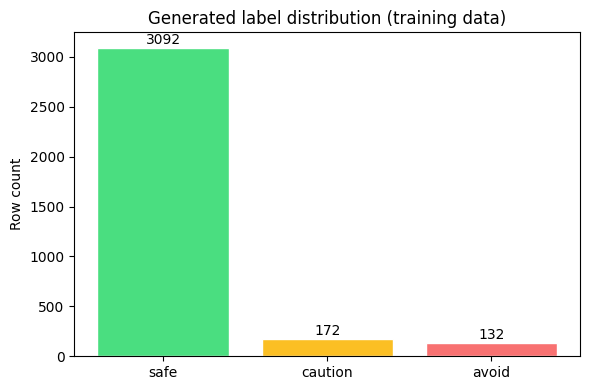

In [11]:
# Visualize label distribution
label_counts = merged['label'].value_counts()
colors = {'safe': '#4ade80', 'caution': '#fbbf24', 'avoid': '#f87171'}
clrs = [colors.get(l, '#60a5fa') for l in label_counts.index]

plt.figure(figsize=(6, 4))
bars = plt.bar(label_counts.index, label_counts.values, color=clrs, edgecolor='white')
plt.title('Generated label distribution (training data)')
plt.ylabel('Row count')
for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom')
plt.tight_layout()
plt.savefig(DATA_DIR + 'label_distribution.png', dpi=100)
plt.show()

## Step 7: Build final ML feature matrix and save

In [12]:
# Feature columns for the ML model
# We use: nutrient values + binary disease flags + encoded demographics
ML_FEATURE_COLS = [
    # Nutrients (from the food/meal)
    'calories', 'carbs', 'fat', 'fiber',
    'protein_target', 'sugar_target', 'sodium_target',
    # Demographics
    'age',
    # Binary disease flags (1=has disease, 0=doesn't)
    'has_weight_gain', 'has_hypertension', 'has_heart_disease',
    'has_kidney_disease', 'has_diabetes', 'has_weight_loss', 'has_acne',
]

# Only keep columns that exist in the DataFrame
final_feature_cols = [c for c in ML_FEATURE_COLS if c in merged.columns]
print('Final feature columns:', final_feature_cols)

# Build the final training dataset
df_ml = merged[final_feature_cols + ['label']].copy()

# Final null check
null_counts = df_ml.isnull().sum()
if null_counts.sum() > 0:
    print('\n⚠ Remaining nulls — filling with 0:')
    print(null_counts[null_counts > 0])
    df_ml = df_ml.fillna(0)
else:
    print('\n✓ No nulls in final feature matrix')

print(f'\nFinal dataset shape: {df_ml.shape}')
df_ml.head(3)

Final feature columns: ['calories', 'carbs', 'fat', 'fiber', 'protein_target', 'sugar_target', 'sodium_target', 'age', 'has_weight_gain', 'has_hypertension', 'has_heart_disease', 'has_kidney_disease', 'has_diabetes', 'has_weight_loss', 'has_acne']

✓ No nulls in final feature matrix

Final dataset shape: (3396, 16)


,calories,carbs,fat,fiber,protein_target,sugar_target,sodium_target,age,has_weight_gain,has_hypertension,has_heart_disease,has_kidney_disease,has_diabetes,has_weight_loss,has_acne,label
0,2020,250,60,30.0,120,125.0,24.0,25,1,0,0,0,0,0,0,safe
1,1480,200,40,24.0,80,100.0,16.0,32,1,1,1,0,0,0,0,safe
2,2185,300,65,36.0,100,150.0,20.0,48,1,0,0,0,0,0,0,safe


In [13]:
# Save the processed training dataset
output_path = DATA_DIR + 'merged_training_data.csv'
df_ml.to_csv(output_path, index=False)
print(f'✓ Saved to {output_path}')
print(f'  Shape : {df_ml.shape}')
print(f'  Labels: {df_ml["label"].value_counts().to_dict()}')
print()
print('This file is the input for 02_model_training.ipynb (Phase 2, Day 9–11)')

✓ Saved to ../backend/app/data/merged_training_data.csv
  Shape : (3396, 16)
  Labels: {'safe': 3092, 'caution': 172, 'avoid': 132}

This file is the input for 02_model_training.ipynb (Phase 2, Day 9–11)


In [14]:
# Also save the feature column list so train_model.py uses the exact same features
import json
feature_list_path = DATA_DIR + 'feature_columns.json'
with open(feature_list_path, 'w') as f:
    json.dump(final_feature_cols, f, indent=2)
print(f'✓ Feature column list saved to {feature_list_path}')
print('  The ML model in Phase 2 will load this to ensure consistent feature ordering.')

✓ Feature column list saved to ../backend/app/data/feature_columns.json
  The ML model in Phase 2 will load this to ensure consistent feature ordering.
